# Lagrangian Transforms using Normalizing Flow Diffeomorphisms

While a pullback over time (using a velocity field) is possible, a more simple alternative is to define direct diffeomorphisms using neural networks, this results in another way to parameterize Lagrangian transformations of basis functions.

In [1]:
%load_ext autoreload
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../..')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_dtype(torch.float64)

Here, we instatiate different normalizing flows that act on the square domain $\Omega = [0, 1]^2$:

In [2]:
%autoreload 2
from infidictionary.diffeomorphisms import UnitCubeNeuralSplineFlow
from infidictionary.diffeomorphisms import UnitSquareKumaraswamy

####
# Toggle between diffeomorphisms here:
# T = UnitCubeNeuralSplineFlow(d=2, hidden_features=64, num_layers=5, num_blocks=2, alpha=0.00005)
T = UnitSquareKumaraswamy(d=2, eps=1e-6, a_min=1, b_min=0.5)

T = T.to(device)

You may toggle between any of the above diffeomirphisms. Here is a brief explanation for each of them:
1. The `UnitCubeNeuralSplineFlow` is based on neural spline flows, a flexible diffeomorphism parameterized using spline couplings. Note that spline flows parmeterize diffeomirphisms on $\mathbb{R}^d$, we therefore perform a coordinatewise logit transform first to map values from $[0, 1]^2$ to $\mathbb{R}^d$, apply the neural spline flow, and then perform an inverse logit (sigmoid) to transform everything back to $[0, 1]^2$.

2. The `UnitSquareKumaraswamy` is based on an elementwise Kumaraswamy transform where each coordinate $x$ is mapped to $1 - (1 - x^a)^b$ and $a$ and $b$ are learnable parameters of the transform. This transformation is a diffeomorphism on $[0, 1]^d$ when applied elementwise and is primarily used for debugging purposes as a simple drop-in flow map.

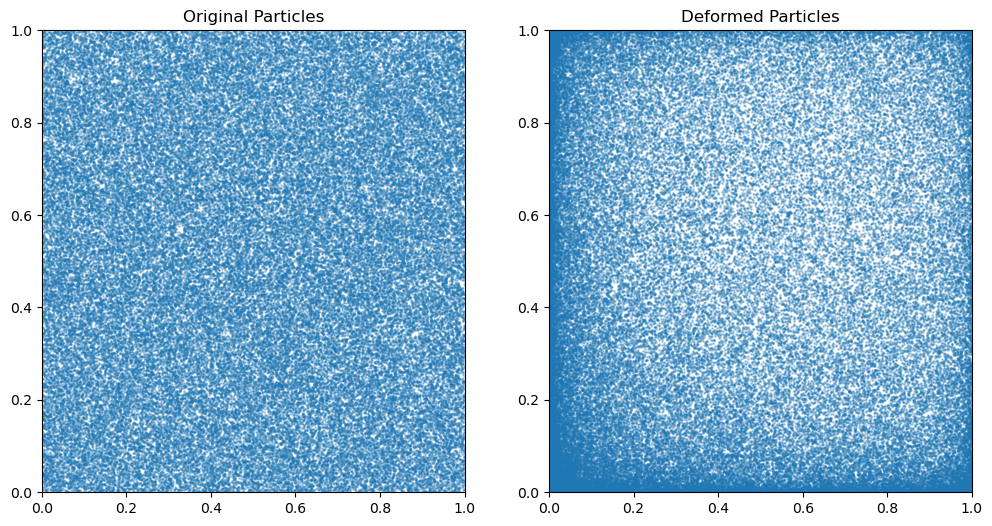

In [3]:
# Sample some points in (0,1)^d
x = torch.rand(8, 2).to(device)
# Forward map and determinant of Jacobian
y, detJ = T.forward(x)
x_rec, detJ_inv = T.inverse(y)

#  check y max and min is in the box
assert (y >= 0).all() and (y <= 1).all(), "Forward map output is out of bounds with values: min {}, max {}".format(y.min().item(), y.max().item())
assert (x - x_rec).abs().max().item() < 1e-6, "Inverse consistency check failed!"
assert (torch.exp(detJ + detJ_inv) - 1).abs().max().item() < 1e-6, "Determinant consistency check failed!"

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,6))
xy = torch.rand(1000_00, 2).to(device)
ax[0].scatter(xy[:,0].detach().cpu(), xy[:,1].detach().cpu(), s=1, alpha=0.3)
ax[0].set_xlim(0,1)
ax[0].set_ylim(0,1)
ax[0].set_title('Original Particles')
transformed_xy, logabsdet = T.forward(xy)
ax[1].scatter(transformed_xy[:,0].detach().cpu(), transformed_xy[:,1].detach().cpu(), s=1, alpha=0.3)
ax[1].set_xlim(0,1)
ax[1].set_ylim(0,1)
ax[1].set_title('Deformed Particles')
plt.show()

Next, deform one of the original bases and see how the heatmap of the inner products changes. Ideally, it should stay the same up to numerical error:

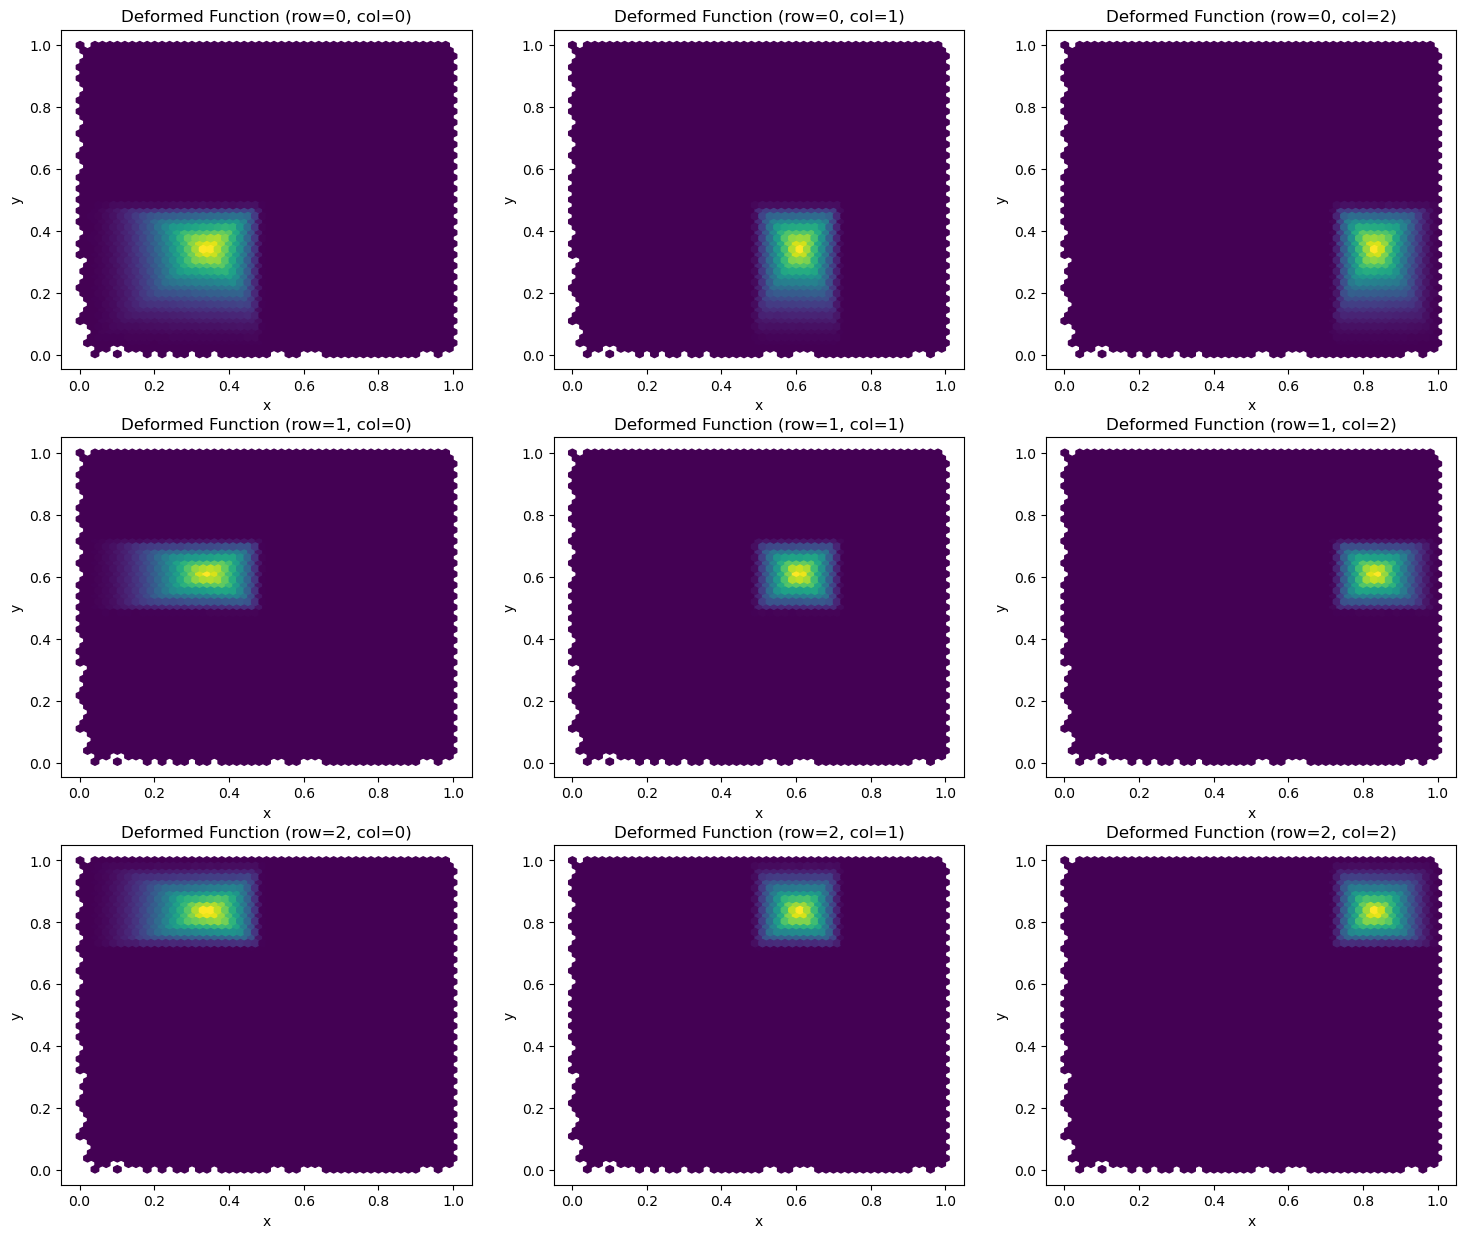

In [4]:
%autoreload 2
from infidictionary.dictionaries import TentDictionary
from infidictionary.domain_samplers import SquareSampler
from infidictionary.neural_isometries import LagrangianIsometry

N_per_dim = 500
isometry = LagrangianIsometry(diffeomorphism=T)
tent_basis = TentDictionary(
    total_cols=3, 
    total_rows=3,
)
indices = [
    [0, 1, 2],
    [3, 4, 5], 
    [6, 7, 8],
]
indices_tensorized = torch.tensor(indices).to(device)
fig, axes = plt.subplots(figsize=(6 * 3,5 * 3), nrows=3, ncols=3)
xy = SquareSampler().sample(N_per_dim).to(device)
all_vals = tent_basis.get_atom(xy, indices_tensorized).unsqueeze(-1)
deformed_xy, logabsdet, all_deformed_vals = isometry.pullback(
    tgt_coords=xy,
    tgt_logabsdet=torch.zeros(xy.shape[0], device=xy.device),
    tgt_field=all_vals,
)
for row in range(3):
    for col in range(3):
        ax = axes[row, col]
        ax.hexbin(
            deformed_xy[:,0].detach().cpu(), 
            deformed_xy[:,1].detach().cpu(), 
            C=all_deformed_vals[row * 3 + col].detach().cpu().squeeze(-1), 
            gridsize=50, 
            cmap='viridis',
        ) 
        ax.set_title(f'Deformed Function (row={row}, col={col})')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
plt.show()
    

Compute the pairwise inner products and compare them before and after deforming the function:

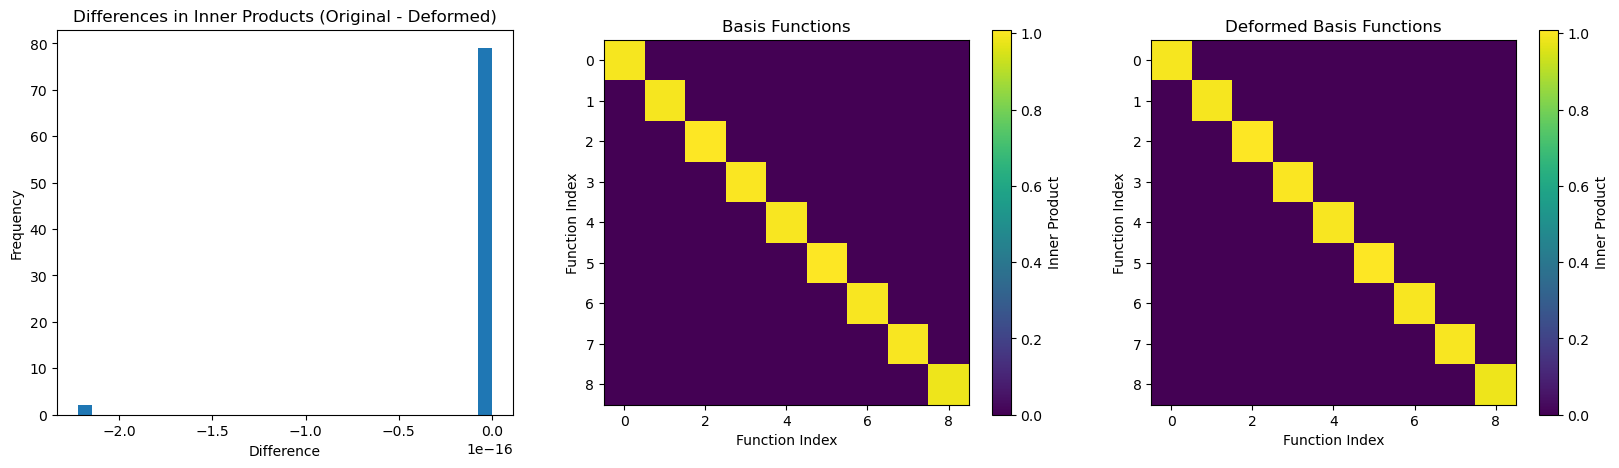

In [5]:
%autoreload 2
from infidictionary.utils import pairwise_inner_product
# compute pairwise inner products
inner_products = pairwise_inner_product(all_vals, all_vals)
inner_products_deformed = pairwise_inner_product(all_deformed_vals, all_deformed_vals, logabsdet=logabsdet)
fig, axes = plt.subplots(figsize=(20, 5), nrows=1, ncols=3)
# heatmap of inner products
m = axes[2].imshow(inner_products_deformed.detach().cpu())
fig.colorbar(m, ax=axes[2], label='Inner Product')
axes[2].set_title('Deformed Basis Functions')
axes[2].set_xlabel('Function Index')
axes[2].set_ylabel('Function Index')

m = axes[1].imshow(inner_products.detach().cpu())
fig.colorbar(m, ax=axes[1], label='Inner Product')
axes[1].set_title('Basis Functions')
axes[1].set_xlabel('Function Index')
axes[1].set_ylabel('Function Index')

diffs = inner_products - inner_products_deformed
axes[0].hist(diffs.flatten().detach().cpu(), bins=30)
axes[0].set_title('Differences in Inner Products (Original - Deformed)')
axes[0].set_xlabel('Difference')
axes[0].set_ylabel('Frequency')
plt.show()


A similar implementation is done for the functions on disk domains. Here, points in the unit disk are first converted to the polar coordinate and rescaled so that everything lies in $[0, 1]^2$, passed through one of the diffeomorphisms defined on $[0, 1]^2$ and then transformed back to the cartesian coordinates. Run the following to visualize the disk domain flows:

In [6]:
%autoreload 2
from infidictionary.diffeomorphisms import UnitCubeNeuralSplineFlow
from infidictionary.diffeomorphisms import UnitSquareKumaraswamy
from infidictionary.diffeomorphisms import DiskFlow

####
# Toggle between diffeomorphisms here:
cubeflow = UnitCubeNeuralSplineFlow(d=2, hidden_features=64, num_layers=5, num_blocks=2, alpha=0.00005)
# cubeflow = UnitSquareKumaraswamy(d=2, eps=1e-6, a_min=1, b_min=0.5)
T = DiskFlow(cubeflow=cubeflow, method='shirley_chiu')

T = T.to(device)


View particles before and after the transform on the unit disk:

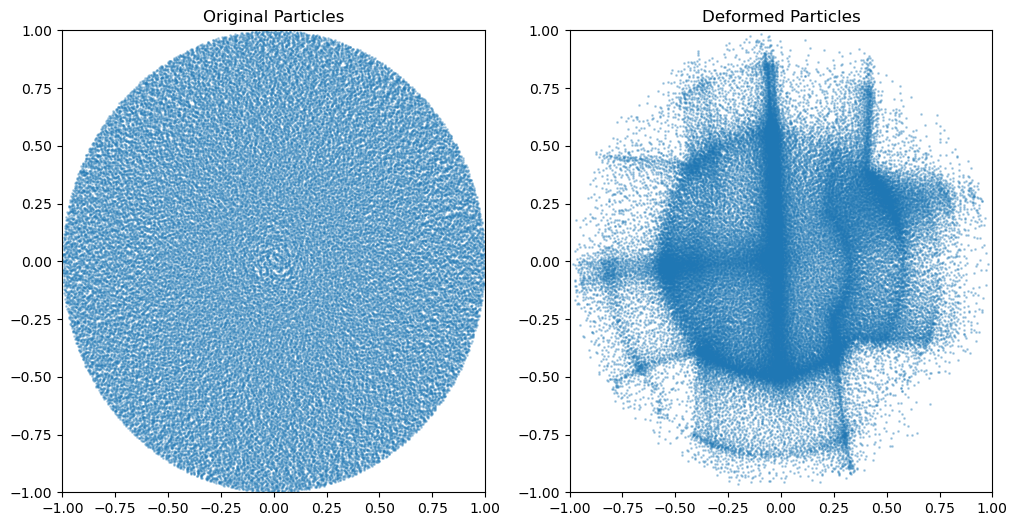

In [14]:
%autoreload 2
from infidictionary.domain_samplers import DiskSampler

N_per_dim = 250
xy = DiskSampler().sample(N_per_dim).to(device)
succ = 0
# check if any of the tensors in T is cpu
for name, param in T.named_parameters():
    if param.device.type == 'cpu':
        print(f"Parameter {name} is on CPU!")
    else:
        succ += 1
# Forward map and determinant of Jacobian
w, detJ = T.forward(xy)
x_rec, detJ_inv = T.inverse(w)

#  check y max and min is in the box
assert (torch.exp(detJ + detJ_inv) - 1).abs().max().item() < 1e-6, "Determinant consistency check failed!"

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,6))
ax[0].scatter(xy[:,0].detach().cpu(), xy[:,1].detach().cpu(), s=1, alpha=0.3)
ax[0].set_xlim(-1,1)
ax[0].set_ylim(-1,1)
ax[0].set_title('Original Particles')
transformed_xy, logabsdet = T.forward(xy)
ax[1].scatter(transformed_xy[:,0].detach().cpu(), transformed_xy[:,1].detach().cpu(), s=1, alpha=0.3)
ax[1].set_xlim(-1,1)
ax[1].set_ylim(-1,1)
ax[1].set_title('Deformed Particles')
plt.show()

Now, we follow a similar thing on the unit disk where visualize the before and after transform of a radial basis:

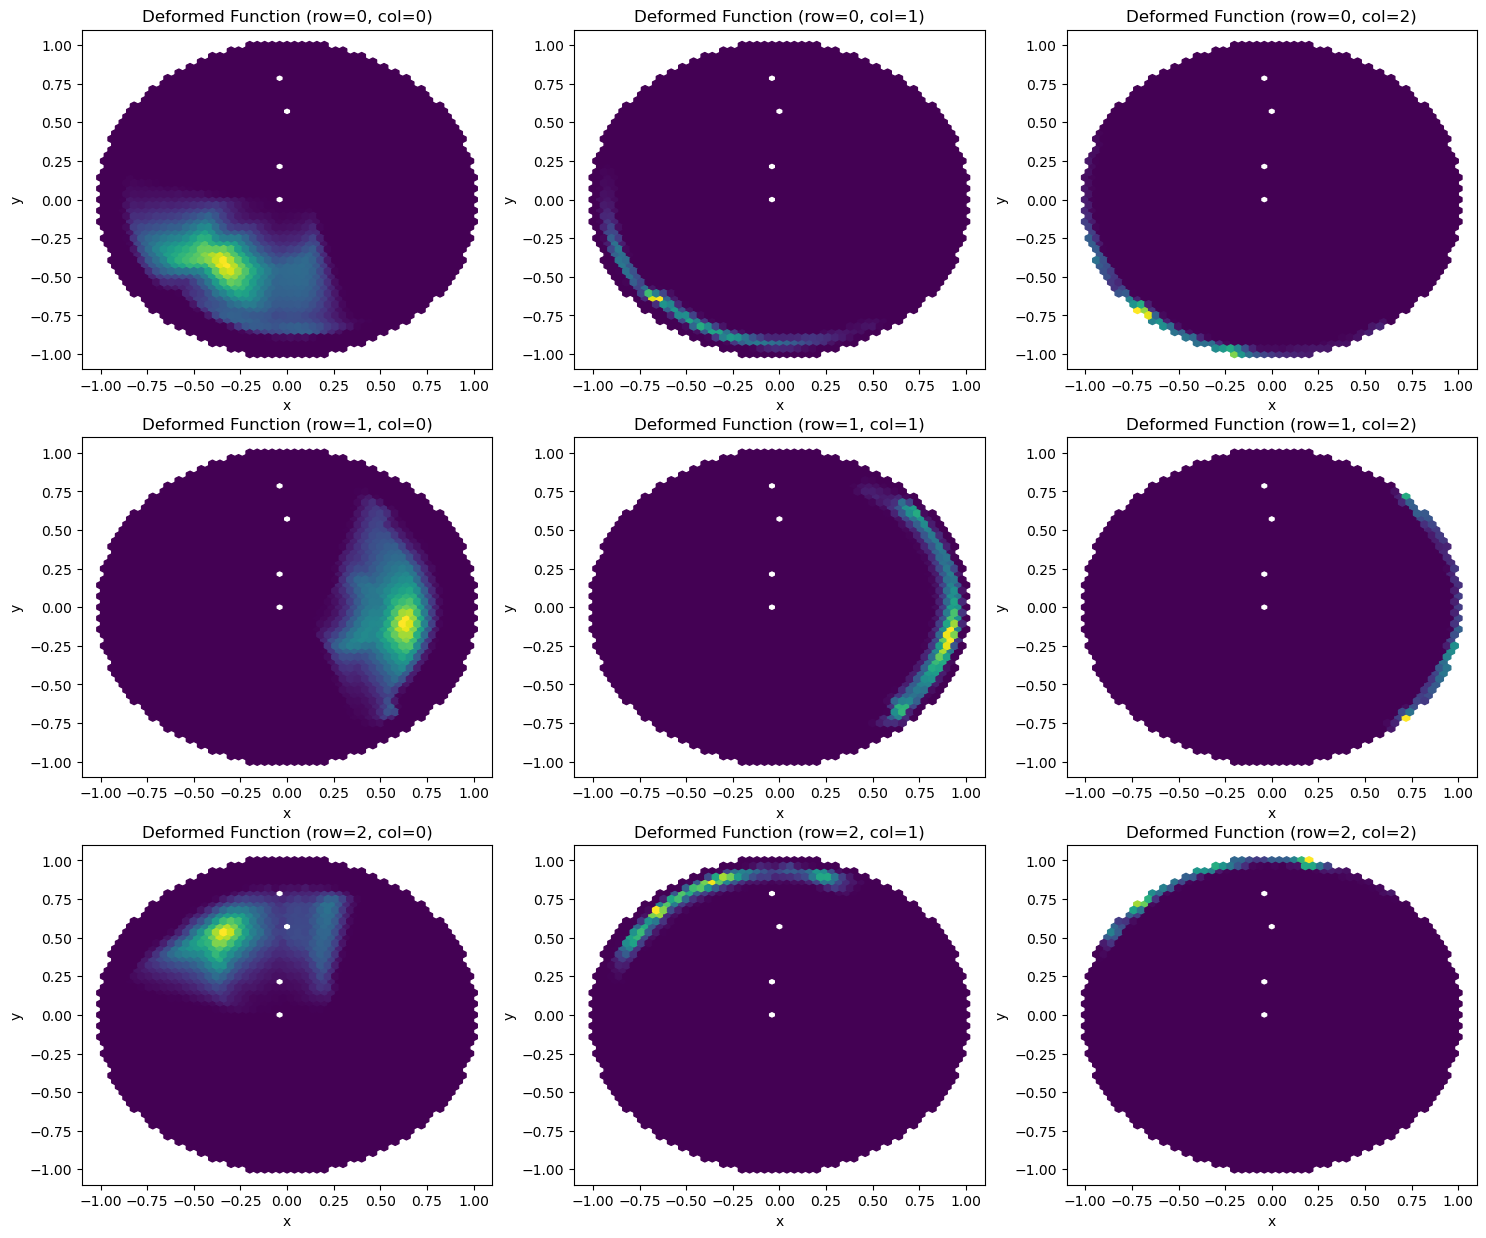

In [15]:
%autoreload 2
from infidictionary.dictionaries import RadialTentDictionary
from infidictionary.neural_isometries import LagrangianIsometry

isometry = LagrangianIsometry(T).to(device)
tent_basis = RadialTentDictionary(
    total_cols=3, 
    total_rows=3,
)
indices = [
    [0, 1, 2],
    [3, 4, 5],
    [6, 7, 8],
]
indices_tensorized = torch.tensor(indices).to(device)
xy = DiskSampler().sample(N_per_dim).to(device)
all_vals = tent_basis.get_atom(xy, indices_tensorized).unsqueeze(-1)
deformed_coords, logabsdet, all_deformed_vals = isometry.pullback(
    tgt_coords=xy,
    tgt_logabsdet=torch.zeros(xy.shape[0], device=xy.device),
    tgt_field=all_vals,
)
fig, axes = plt.subplots(figsize=(6 * 3,5 * 3), nrows=3, ncols=3)
for row in range(3):
    for col in range(3):
        ax = axes[row, col]
        ax.hexbin(
            deformed_coords[:,0].detach().cpu(), 
            deformed_coords[:,1].detach().cpu(), 
            C=all_deformed_vals[row * 3 + col].detach().cpu().squeeze(-1), 
            gridsize=50, 
            cmap='viridis',
        ) 
        ax.set_title(f'Deformed Function (row={row}, col={col})')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
plt.show()
    

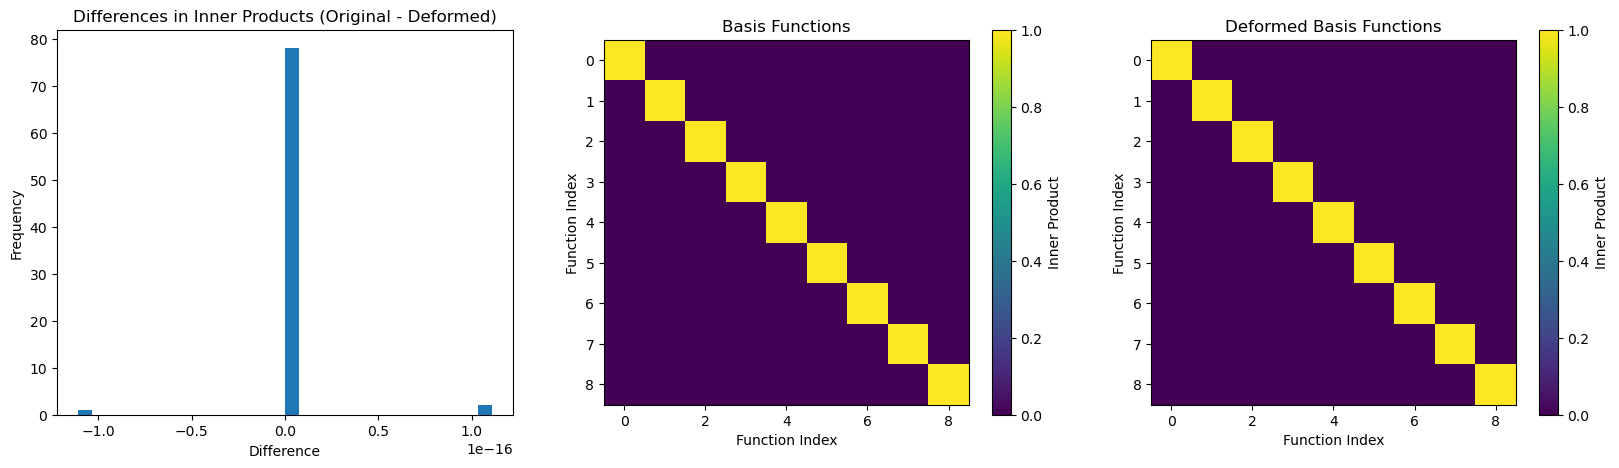

In [16]:
%autoreload 2
from infidictionary.utils import pairwise_inner_product
# compute pairwise inner products
inner_products = pairwise_inner_product(all_vals, all_vals)
inner_products_deformed = pairwise_inner_product(all_deformed_vals, all_deformed_vals, logabsdet=logabsdet)

fig, axes = plt.subplots(figsize=(20, 5), nrows=1, ncols=3)
# heatmap of inner products
m = axes[2].imshow(inner_products_deformed.detach().cpu())
fig.colorbar(m, ax=axes[2], label='Inner Product')
axes[2].set_title('Deformed Basis Functions')
axes[2].set_xlabel('Function Index')
axes[2].set_ylabel('Function Index')

m = axes[1].imshow(inner_products.detach().cpu())
fig.colorbar(m, ax=axes[1], label='Inner Product')
axes[1].set_title('Basis Functions')
axes[1].set_xlabel('Function Index')
axes[1].set_ylabel('Function Index')

diffs = inner_products - inner_products_deformed
axes[0].hist(diffs.flatten().detach().cpu(), bins=30)
axes[0].set_title('Differences in Inner Products (Original - Deformed)')
axes[0].set_xlabel('Difference')
axes[0].set_ylabel('Frequency')
plt.show()
